In [ ]:
%pip install torch torchvision

In [ ]:
%unzip data.zip

Archive:  data.zip
   creating: data/
   creating: data/Potato_Early_blight/
  inflating: data/Potato_Early_blight/2d149f7a-4b0a-40a6-8d0b-1d1f14e5e696___RS_Early.B 9143.JPG  
  inflating: data/Potato_Early_blight/b4021eae-d195-400a-b7b7-9888367f5f2f___RS_Early.B 7881.JPG  
  inflating: data/Potato_Early_blight/23546e04-7151-4dbd-95a1-687d963eb132___RS_Early.B 7402.JPG  
  inflating: data/Potato_Early_blight/1daae61a-7014-4efe-b855-018999a5be9b___RS_Early.B 6852.JPG  
  inflating: data/Potato_Early_blight/8994b76b-6e1e-42d3-b07c-99abca3fa35b___RS_Early.B 7762.JPG  
  inflating: data/Potato_Early_blight/f400079a-ff67-45c2-8a50-5c5b1e08dc25___RS_Early.B 8491.JPG  
  inflating: data/Potato_Early_blight/96ab8c2b-9067-4af7-821c-b14a3c7e618f___RS_Early.B 8816.JPG  
  inflating: data/Potato_Early_blight/6d1cebfa-ad84-484e-9f30-f8fffb289072___RS_Early.B 7703.JPG  
  inflating: data/Potato_Early_blight/5c3363d5-5873-40f5-b179-37ab6df0328c___RS_Early.B 8828.JPG  
  inflating: data/Potato_Early_b

In [ ]:
ColorChannels = 3
ImageSize = (256, 256)
BatchSize = 32

import torch
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

train_transform = transforms.Compose([
    transforms.Resize(ImageSize),
    transforms.RandomHorizontalFlip(p=0.25),
    transforms.RandomRotation(20),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor() 
])

val_test_transform = transforms.Compose([
    transforms.Resize(ImageSize),
    transforms.ToTensor() 
])

dataset = ImageFolder(
    root = "data/"
)

print(dataset.classes) # ['Potato_Early_blight', 'Potato_Late_blight', 'Potato_healthy']
print(dataset.class_to_idx) # {'Potato_Early_blight': 0, 'Potato_Late_blight': 1, 'Potato_healthy': 2}

### Train/Test Split ###
N = len(dataset)

train_size = int(0.8 * N)
val_size = int(0.1 * N)
test_size = N - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

train_loader = DataLoader(
    train_dataset,
    batch_size = BatchSize,
    shuffle = True
)
print(len(train_loader)) # 54

val_loader = DataLoader(
    val_dataset,
    batch_size = BatchSize,
    shuffle = False
)
print(len(val_loader))  # 7

test_loader = DataLoader(
    test_dataset,
    batch_size = BatchSize,
    shuffle = False
)
print(len(test_loader)) # 7

import torch
import torch.nn as nn
import torch.optim as optim
# from torchvision import models
# from torchvision.models import mobilenet_v2

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = nn.Sequential(
    nn.Conv2d(
        in_channels=ColorChannels,
        out_channels=16,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d((1,1)),
    nn.Flatten(),
    nn.Linear(
        in_features=64,
        out_features=128
    ),
    nn.ReLU(),
    nn.Linear(
        in_features=128,
        out_features=3
    )
)

# model = mobilenet_v2(weights="DEFAULT")
# model.classifier[1] = nn.Linear(
#     model.classifier[1].in_features,
#     3
# )

# model = models.resnet18(pretrained=True)
# model.fc = nn.Linear(
#     model.fc.in_features,
#     3
# )

model = model.to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}%"
    )
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )
    print("-" * 50)

['Potato_Early_blight', 'Potato_Late_blight', 'Potato_healthy']
{'Potato_Early_blight': 0, 'Potato_Late_blight': 1, 'Potato_healthy': 2}
54
7
7
Epoch [1/20]
Train Loss: 0.9417 | Train Accuracy: 44.92%
Val Loss: 0.9017 | Val Accuracy: 74.42%
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.7365 | Train Accuracy: 73.91%
Val Loss: 0.6023 | Val Accuracy: 74.88%
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.5477 | Train Accuracy: 80.19%
Val Loss: 0.5798 | Val Accuracy: 79.07%
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.4258 | Train Accuracy: 86.58%
Val Loss: 0.3715 | Val Accuracy: 88.84%
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.4403 | Train Accuracy: 84.95%
Val Loss: 0.3407 | Val Accuracy: 90.23%
--------------------------------------------------
Epoch [6/20]
Train Loss: 0.3540 | Train Accuracy: 88.15%
Val Loss: 0.3472 | Val Accuracy: 86.98%
-------------------

In [ ]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 96.76%


In [ ]:
torch.save(model.state_dict(), "model1.pth")

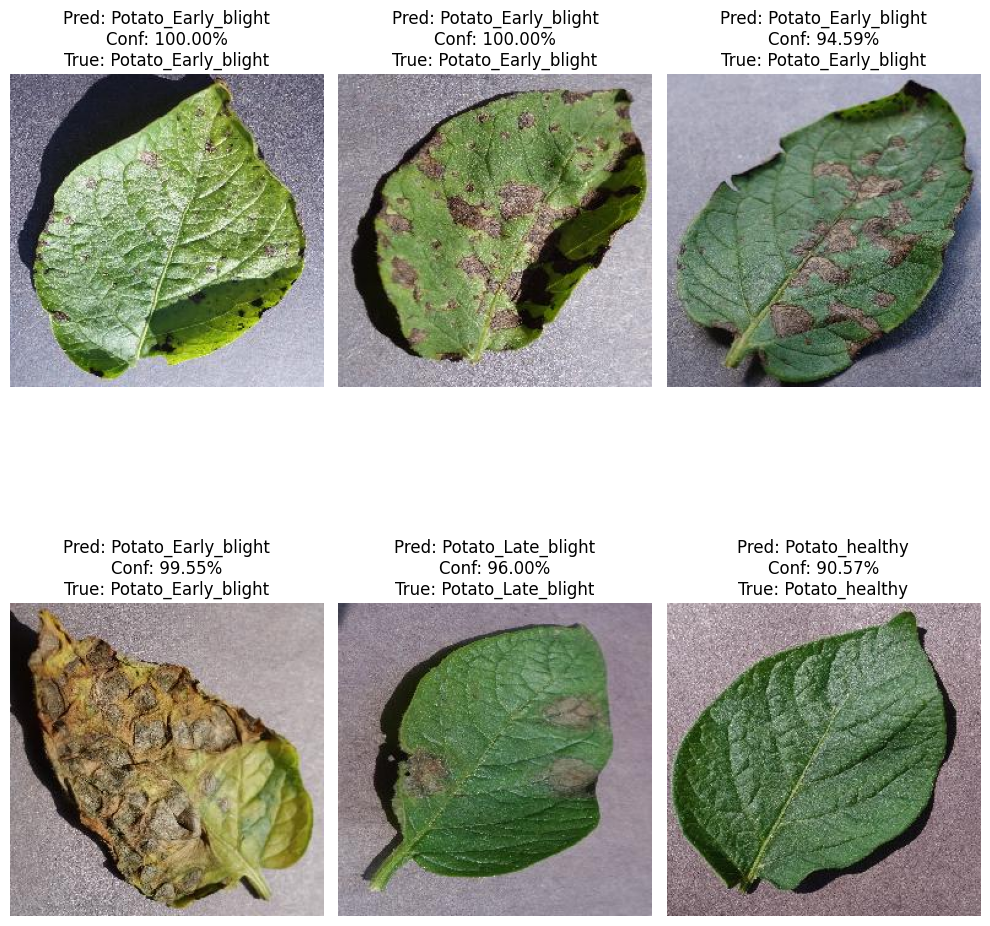

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

model.eval()

fig, axes = plt.subplots(2, 3, figsize=(10, 12))
axes = axes.flatten()

with torch.no_grad():
    for ax in axes:

        idx = torch.randint(0, len(test_dataset), (1,)).item()

        image, true_label = test_dataset[idx]

        # Add batch dimension
        input_tensor = image.unsqueeze(0).to(device)

        logits = model(input_tensor)

        probs = F.softmax(logits, dim=1)

        confidence, pred_class = torch.max(probs, dim=1)

        pred_class = pred_class.item()
        confidence = confidence.item()

        # Convert tensor -> HWC for matplotlib
        img_np = image.permute(1, 2, 0).cpu().numpy()

        ax.imshow(img_np)

        ax.set_title(
            f"Pred: {dataset.classes[pred_class]}\n"
            f"Conf: {confidence:.2%}\n"
            f"True: {dataset.classes[true_label]}"
        )

        ax.axis("off")

plt.tight_layout()
plt.show()